# Hands segmentation


## Getting started
First, we check the version of Tensorflow and set the seeds for reproducibility.

In [ ]:
import tensorflow as tf
import numpy as np
import os
import random

seed = 42
def set_seed(seedValue=42):
  """Sets the seed on multiple python modules to obtain results as
  reproducible as possible.
  Args:
  seedValue (int, optional): seed value.
  """
  np.random.seed(seed=seedValue)
  tf.random.set_seed(seedValue)
  os.environ["PYTHONHASHSEED"]=str(seedValue)
  random.seed(seedValue)
set_seed(seed)

print( tf.__version__ )

2.8.2


## Utilities
(functions and classes)

### Load data functions

In [ ]:
import os
from skimage.util import img_as_ubyte
from skimage import io
from matplotlib import pyplot as plt
from glob import glob

def get_xy_image_list(dir):
    if dir[-1]=='/':
        dir = dir[:-1]
    # Paths to the training images and their corresponding labels
    train_input_path = dir + '/x/*.*'
    train_label_path = dir + '/y/*.*'

    # Read the list of file names
    train_input_filenames = glob(train_input_path)
    train_input_filenames.sort()

    train_label_filenames = glob(train_label_path)
    train_label_filenames.sort()

    print( 'Input images loaded: {} -- Label images loaded: {}\n\tpath: {}'.format(len(train_input_filenames), len(train_label_filenames), dir) )

    # read training images and labels
    train_img = [ img_as_ubyte( np.array(io.imread( x ), dtype='uint8') ) for x in train_input_filenames ]
    train_lbl = [ img_as_ubyte( np.array(io.imread( x ), dtype='uint8') ) for x in train_label_filenames ]

    return train_img, train_lbl

def create_patches( imgs, num_x_patches, num_y_patches ):
    ''' Create a list of images patches out of a list of images
    Args:
        imgs: list of input images
        num_x_patches: number of patches in the X axis
        num_y_patches: number of patches in the Y axis

    Returns:
        list of image patches
    '''
    original_size = imgs[0].shape
    patch_width = original_size[ 0 ] // num_y_patches
    patch_height = original_size[ 1 ] // num_x_patches

    patches = []
    for n in range( 0, len( imgs ) ):
        image = imgs[ n ]
        for i in range( 0, num_y_patches ):
            for j in range( 0, num_x_patches ):
                patches.append( image[ i * patch_width : (i+1) * patch_width,
                                      j * patch_height : (j+1) * patch_height ] )
    return patches

# We define a method to create an arbitrary number of random crops of
# a given size
def create_random_patches( input_imgs, lbl_imgs, num_patches,
                          shape ):
    ''' Create a list of images patches out of a list of images
    Args:
        input_imgs: list of input images
        lbl_imgs: list of input images
        num_patches (int): number of patches for each image.
        shape (2D array): size of the LR patches. Example: [128, 128].

    Returns:
        list of image patches and patches of corresponding labels
    '''

    # read training images
    img = input_imgs[0]

    original_size = img.shape

    input_patches = []
    label_patches = []
    for n in range( 0, len( input_imgs ) ):
        img = input_imgs[n]
        lbl = lbl_imgs[n]
        for i in range( num_patches ):
          r = np.random.randint(0,original_size[0]-shape[0])
          c = np.random.randint(0,original_size[1]-shape[1])
          input_patches.append(  img[ r : r + shape[0],
                                  c : c + shape[1] ] )
          label_patches.append( lbl[ r : r + shape[0],
                                  c : c + shape[1] ] )
    return input_patches, label_patches

In [ ]:
from PIL import Image

def add_padding(np_img):
    '''
    Given a numpy array, add padding to the image so that the image is a multiple of 256x256

    Args:
      np_img: the image to be padded

    Returns:
      A numpy array of the image with the padding added.
    '''

    image = Image.fromarray(np_img)
    height, width = np_img.shape

    if not width%256 and not height%256:
        return np_img

    x = width/256
    y = height/256

    new_width = int(np.ceil(x))*256
    new_height = int(np.ceil(y))*256

    left = int( (new_width - width)/2 )
    top = int( (new_height - height)/2 )

    result = Image.new(image.mode, (new_width, new_height), 0)

    result.paste(image, (left, top))

    return np.asarray(result)

In [ ]:
def filter_patches(img_list, lbl_list, zeros_perc = 0.5):
    resul_img_list = []
    resul_lbl_list = []
    for img, lbl in zip(img_list, lbl_list):
        img_hist,_ = np.histogram(np.array(img).ravel(), bins=np.arange(256))
        #print(img_hist[0]/np.sum(img_hist))
        if img_hist[0]/np.sum(img_hist) < zeros_perc : # 0s are less than the x% of the image
            # only_filt_zeros
            resul_img_list.append(img)
            resul_lbl_list.append(lbl)
    return resul_img_list, resul_lbl_list
#source_img_f, source_lbl_f = filter_patches(source_img, source_lbl)

In [ ]:
import math

# https://github.com/danifranco/EM_Image_Segmentation/blob/6499778fa619c9d623229484e6db2ea23f8c84e9/data/data_2D_manipulation.py#L230
def crop_data_with_overlap(data, crop_shape, data_mask=None, overlap=(0,0), padding=(0,0), verbose=True):
    """Crop data into small square pieces with overlap. The difference with :func:`~crop_data` is that this function
       allows you to create patches with overlap.
       The opposite function is :func:`~merge_data_with_overlap`.
       Parameters
       ----------
       data : 4D Numpy array
           Data to crop. E.g. ``(num_of_images, x, y, channels)``.
       crop_shape : 3 int tuple
           Shape of the crops to create. E.g. ``(x, y, channels)``.
       data_mask : 4D Numpy array, optional
           Data mask to crop. E.g. ``(num_of_images, x, y, channels)``.
       overlap : Tuple of 2 floats, optional
           Amount of minimum overlap on x and y dimensions. The values must be on range ``[0, 1)``, that is, ``0%`` or
           ``99%`` of overlap. E. g. ``(x, y)``.
       padding : tuple of ints, optional
           Size of padding to be added on each axis ``(x, y)``. E.g. ``(24, 24)``.
       verbose : bool, optional
            To print information about the crop to be made.
       Returns
       -------
       cropped_data : 4D Numpy array
           Cropped image data. E.g. ``(num_of_images, x, y, channels)``.
       cropped_data_mask : 4D Numpy array, optional
           Cropped image data masks. E.g. ``(num_of_images, x, y, channels)``.
       Examples
       --------
       ::
           # EXAMPLE 1
           # Divide in crops of (256, 256) a given data with the minimum overlap
           X_train = np.ones((165, 768, 1024, 1))
           Y_train = np.ones((165, 768, 1024, 1))
           X_train, Y_train = crop_data_with_overlap(X_train, (256, 256, 1), Y_train, (0, 0))
           # Notice that as the shape of the data has exact division with the wnanted crops shape so no overlap will be
           # made. The function will print the following information:
           #     Minimum overlap selected: (0, 0)
           #     Real overlapping (%): (0.0, 0.0)
           #     Real overlapping (pixels): (0.0, 0.0)
           #     (3, 4) patches per (x,y) axis
           #     **** New data shape is: (1980, 256, 256, 1)
           # EXAMPLE 2
           # Same as example 1 but with 25% of overlap between crops
           X_train, Y_train = crop_data_with_overlap(X_train, (256, 256, 1), Y_train, (0.25, 0.25))
           # The function will print the following information:
           #     Minimum overlap selected: (0.25, 0.25)
           #     Real overlapping (%): (0.33203125, 0.3984375)
           #     Real overlapping (pixels): (85.0, 102.0)
           #     (4, 6) patches per (x,y) axis
           #     **** New data shape is: (3960, 256, 256, 1)
           # EXAMPLE 3
           # Same as example 1 but with 50% of overlap between crops
           X_train, Y_train = crop_data_with_overlap(X_train, (256, 256, 1), Y_train, (0.5, 0.5))
           # The function will print the shape of the created array. In this example:
           #     Minimum overlap selected: (0.5, 0.5)
           #     Real overlapping (%): (0.59765625, 0.5703125)
           #     Real overlapping (pixels): (153.0, 146.0)
           #     (6, 8) patches per (x,y) axis
           #     **** New data shape is: (7920, 256, 256, 1)
           # EXAMPLE 4
           # Same as example 2 but with 50% of overlap only in x axis
           X_train, Y_train = crop_data_with_overlap(X_train, (256, 256, 1), Y_train, (0.5, 0))
           # The function will print the shape of the created array. In this example:
           #     Minimum overlap selected: (0.5, 0)
           #     Real overlapping (%): (0.59765625, 0.0)
           #     Real overlapping (pixels): (153.0, 0.0)
           #     (6, 4) patches per (x,y) axis
           #     **** New data shape is: (3960, 256, 256, 1)
    """

    if data_mask is not None:
        if data.shape[:-1] != data_mask.shape[:-1]:
            raise ValueError("data and data_mask shapes mismatch: {} vs {}".format(data.shape[:-1], data_mask.shape[:-1]))

    if verbose:
        print("### OV-CROP ###")
        print("Cropping {} images into {} with overlapping. . ."\
              .format(data.shape, crop_shape))
        print("Minimum overlap selected: {}".format(overlap))
        print("Padding: {}".format(padding))

    if (overlap[0] >= 1 or overlap[0] < 0) and (overlap[1] >= 1 or overlap[1] < 0):
        raise ValueError("'overlap' values must be floats between range [0, 1)")

    padded_data = np.zeros((data.shape[0], data.shape[1]+2*padding[0], data.shape[2]+2*padding[1], data.shape[3]))
    padded_data[:, padding[0]:padding[0]+data.shape[1], padding[1]:padding[1]+data.shape[2], :] = data

    if data_mask is not None:
        padded_data_mask = np.zeros((data_mask.shape[0], data_mask.shape[1]+2*padding[0],
                                     data_mask.shape[2]+2*padding[1], data_mask.shape[3]))
        padded_data_mask[:, padding[0]:padding[0]+data_mask.shape[1],
                         padding[1]:padding[1]+data_mask.shape[2], :] = data_mask

    padded_crop_shape = crop_shape
    crop_shape = (crop_shape[0]-2*padding[0], crop_shape[1]-2*padding[1], crop_shape[2])

    # Calculate overlapping variables
    overlap_x = 1 if overlap[0] == 0 else 1-overlap[0]
    overlap_y = 1 if overlap[1] == 0 else 1-overlap[1]

    # X
    crops_per_x = math.ceil(data.shape[1]/(crop_shape[0]*overlap_x))
    excess_x = int((crops_per_x*crop_shape[0])-((crops_per_x-1)*overlap[0]*crop_shape[0]))-data.shape[1]
    ex = 0 if crops_per_x == 1 else int(excess_x/(crops_per_x-1))
    step_x = int(crop_shape[0]*overlap_x)-ex
    last_x = 0 if crops_per_x == 1 else excess_x%(crops_per_x-1)

    # Y
    crops_per_y = math.ceil(data.shape[2]/(crop_shape[1]*overlap_y))
    excess_y = int((crops_per_y*crop_shape[1])-((crops_per_y-1)*overlap[1]*crop_shape[1]))-data.shape[2]
    ex = 0 if crops_per_y == 1 else int(excess_y/(crops_per_y-1))
    step_y = int(crop_shape[1]*overlap_y)-ex
    last_y = 0 if crops_per_y == 1 else excess_y%(crops_per_y-1)

    # Real overlap calculation for printing
    real_ov_x = (crop_shape[0]-step_x)/crop_shape[0]
    real_ov_y = (crop_shape[1]-step_y)/crop_shape[1]
    if verbose:
        print("Real overlapping (%): {}".format((real_ov_x,real_ov_y)))
        print("Real overlapping (pixels): {}".format((crop_shape[0]*real_ov_x, crop_shape[1]*real_ov_y)))
        print("{} patches per (x,y) axis".format((crops_per_x,crops_per_y)))

    total_vol = data.shape[0]*(crops_per_x)*(crops_per_y)
    cropped_data = np.zeros((total_vol,) + padded_crop_shape, dtype=data.dtype)
    if data_mask is not None:
        cropped_data_mask = np.zeros((total_vol,)+padded_crop_shape[:2]+(data_mask.shape[-1],), dtype=data_mask.dtype)

    c = 0
    for z in range(data.shape[0]):
        for x in range(crops_per_x):
            for y in range(crops_per_y):
                d_x = 0 if (x*step_x+crop_shape[0]) < data.shape[1] else last_x
                d_y = 0 if (y*step_y+crop_shape[1]) < data.shape[2] else last_y

                cropped_data[c] = \
                    padded_data[z,
                                x*step_x-d_x:x*step_x+crop_shape[0]-d_x+2*padding[0],
                                y*step_y-d_y:y*step_y+crop_shape[1]-d_y+2*padding[1]]

                if data_mask is not None:
                    cropped_data_mask[c] = \
                        padded_data_mask[z,
                                         x*step_x-d_x:x*step_x+crop_shape[0]-d_x+2*padding[0],
                                         y*step_y-d_y:y*step_y+crop_shape[1]-d_y+2*padding[1]]
                c += 1

    if verbose:
        print("**** New data shape is: {}".format(cropped_data.shape))
        print("### END OV-CROP ###")

    if data_mask is not None:
        return cropped_data, cropped_data_mask
    else:
        return

In [ ]:
# https://github.com/danifranco/EM_Image_Segmentation/blob/6499778fa619c9d623229484e6db2ea23f8c84e9/data/data_2D_manipulation.py#L407
def merge_data_with_overlap(data, original_shape, data_mask=None, overlap=(0,0), padding=(0,0), verbose=True,
    out_dir=None, prefix=""):
    """Merge data with an amount of overlap.
       The opposite function is :func:`~crop_data_with_overlap`.
       Parameters
       ----------
       data : 4D Numpy array
           Data to merge. E.g. ``(num_of_images, x, y, channels)``.
       original_shape : 4D int tuple
           Shape of the original data. E.g. ``(num_of_images, x, y, channels)``
       data_mask : 4D Numpy array, optional
           Data mask to merge. E.g. ``(num_of_images, x, y, channels)``.
       overlap : Tuple of 2 floats, optional
           Amount of minimum overlap on x, y and z dimensions. Should be the same as used in
           :func:`~crop_data_with_overlap`. The values must be on range ``[0, 1)``, that is, ``0%`` or ``99%`` of
           overlap. E. g. ``(x, y)``.
       padding : tuple of ints, optional
           Size of padding to be added on each axis ``(x, y)``. E.g. ``(24, 24)``.
       verbose : bool, optional
            To print information about the crop to be made.
       out_dir : str, optional
           If provided an image that represents the overlap made will be saved. The image will be colored as follows:
           green region when ``==2`` crops overlap, yellow when ``2 < x < 6`` and red when ``=<6`` or more crops are
           merged.
       prefix : str, optional
           Prefix to save overlap map with.
       Returns
       -------
       merged_data : 4D Numpy array
           Merged image data. E.g. ``(num_of_images, x, y, channels)``.
       merged_data_mask : 4D Numpy array, optional
           Merged image data mask. E.g. ``(num_of_images, x, y, channels)``.
       Examples
       --------
       ::
           # EXAMPLE 1
           # Merge the data of example 1 of 'crop_data_with_overlap' function
           # 1) CROP
           X_train = np.ones((165, 768, 1024, 1))
           Y_train = np.ones((165, 768, 1024, 1))
           X_train, Y_train = crop_data_with_overlap(X_train, (256, 256, 1), Y_train, (0, 0))
           # 2) MERGE
           X_train, Y_train = merge_data_with_overlap(
               X_train, (165, 768, 1024, 1), Y_train, (0, 0), out_dir='out_dir')
           # The function will print the following information:
           #     Minimum overlap selected: (0, 0)
           #     Real overlapping (%): (0.0, 0.0)
           #     Real overlapping (pixels): (0.0, 0.0)
           #     (3, 4) patches per (x,y) axis
           #     **** New data shape is: (165, 768, 1024, 1)
           # EXAMPLE 2
           # Merge the data of example 2 of 'crop_data_with_overlap' function
           X_train, Y_train = merge_data_with_overlap(
                X_train, (165, 768, 1024, 1), Y_train, (0.25, 0.25), out_dir='out_dir')
           # The function will print the following information:
           #     Minimum overlap selected: (0.25, 0.25)
           #     Real overlapping (%): (0.33203125, 0.3984375)
           #     Real overlapping (pixels): (85.0, 102.0)
           #     (3, 5) patches per (x,y) axis
           #     **** New data shape is: (165, 768, 1024, 1)
           # EXAMPLE 3
           # Merge the data of example 3 of 'crop_data_with_overlap' function
           X_train, Y_train = merge_data_with_overlap(
               X_train, (165, 768, 1024, 1), Y_train, (0.5, 0.5), out_dir='out_dir')
           # The function will print the shape of the created array. In this example:
           #     Minimum overlap selected: (0.5, 0.5)
           #     Real overlapping (%): (0.59765625, 0.5703125)
           #     Real overlapping (pixels): (153.0, 146.0)
           #     (6, 8) patches per (x,y) axis
           #     **** New data shape is: (165, 768, 1024, 1)
           # EXAMPLE 4
           # Merge the data of example 1 of 'crop_data_with_overlap' function
           X_train, Y_train = merge_data_with_overlap(
               X_train, (165, 768, 1024, 1), Y_train, (0.5, 0), out_dir='out_dir')
           # The function will print the shape of the created array. In this example:
           #     Minimum overlap selected: (0.5, 0)
           #     Real overlapping (%): (0.59765625, 0.0)
           #     Real overlapping (pixels): (153.0, 0.0)
           #     (6, 4) patches per (x,y) axis
           #     **** New data shape is: (165, 768, 1024, 1)
       As example of different overlap maps are presented below.
       +--------------------------------------------+--------------------------------------------+
       | .. figure:: ../img/merged_ov_map_0.png     | .. figure:: ../img/merged_ov_map_0.25.png  |
       |   :width: 80%                              |   :width: 80%                              |
       |   :align: center                           |   :align: center                           |
       |                                            |                                            |
       |   Example 1 overlapping map                |   Example 2 overlapping map                |
       +--------------------------------------------+--------------------------------------------+
       | .. figure:: ../img/merged_ov_map_0.5.png   | .. figure:: ../img/merged_ov_map_0.5inx.png|
       |   :width: 80%                              |   :width: 80%                              |
       |   :align: center                           |   :align: center                           |
       |                                            |                                            |
       |   Example 3 overlapping map                |   Example 4 overlapping map                |
       +--------------------------------------------+--------------------------------------------+
    """

    if data_mask is not None:
        if data.shape[:-1] != data_mask.shape[:-1]:
            raise ValueError("data and data_mask shapes mismatch: {} vs {}".format(data.shape[:-1], data_mask.shape[:-1]))

    if verbose:
        print("### MERGE-OV-CROP ###")
        print("Merging {} images into {} with overlapping . . .".format(data.shape, original_shape))
        print("Minimum overlap selected: {}".format(overlap))
        print("Padding: {}".format(padding))

    if (overlap[0] >= 1 or overlap[0] < 0) and (overlap[1] >= 1 or overlap[1] < 0):
        raise ValueError("'overlap' values must be floats between range [0, 1)")

    # Remove the padding
    data = data[:, padding[0]:data.shape[1]-padding[0], padding[1]:data.shape[2]-padding[1], :]

    merged_data = np.zeros((original_shape), dtype=data.dtype)
    if data_mask is not None:
        merged_data_mask = np.zeros((original_shape), dtype=data_mask.dtype)
        data_mask = data_mask[:, padding[0]:data_mask.shape[1]-padding[0], padding[1]:data_mask.shape[2]-padding[1], :]

    ov_map_counter = np.zeros(original_shape, dtype=np.int32)
    if out_dir is not None:
        crop_grid = np.zeros(original_shape[1:], dtype=np.int32)

    # Calculate overlapping variables
    overlap_x = 1 if overlap[0] == 0 else 1-overlap[0]
    overlap_y = 1 if overlap[1] == 0 else 1-overlap[1]

    # X
    crops_per_x = math.ceil(original_shape[1]/(data.shape[1]*overlap_x))
    excess_x = int((crops_per_x*data.shape[1])-((crops_per_x-1)*overlap[0]*data.shape[1]))-original_shape[1]
    ex = 0 if crops_per_x == 1 else int(excess_x/(crops_per_x-1))
    step_x = int(data.shape[1]*overlap_x)-ex
    last_x = 0 if crops_per_x == 1 else excess_x%(crops_per_x-1)

    # Y
    crops_per_y = math.ceil(original_shape[2]/(data.shape[2]*overlap_y))
    excess_y = int((crops_per_y*data.shape[2])-((crops_per_y-1)*overlap[1]*data.shape[2]))-original_shape[2]
    ex = 0 if crops_per_y == 1 else int(excess_y/(crops_per_y-1))
    step_y = int(data.shape[2]*overlap_y)-ex
    last_y = 0 if crops_per_y == 1 else excess_y%(crops_per_y-1)

    # Real overlap calculation for printing
    real_ov_x = (data.shape[1]-step_x)/data.shape[1]
    real_ov_y = (data.shape[2]-step_y)/data.shape[2]
    if verbose:
        print("Real overlapping (%): {}".format((real_ov_x,real_ov_y)))
        print("Real overlapping (pixels): {}".format((data.shape[1]*real_ov_x, data.shape[2]*real_ov_y)))
        print("{} patches per (x,y) axis".format((crops_per_x,crops_per_y)))

    c = 0
    for z in range(original_shape[0]):
        for x in range(crops_per_x):
            for y in range(crops_per_y):
                d_x = 0 if (x*step_x+data.shape[1]) < original_shape[1] else last_x
                d_y = 0 if (y*step_y+data.shape[2]) < original_shape[2] else last_y

                merged_data[z, x*step_x-d_x:x*step_x+data.shape[1]-d_x, y*step_y-d_y:y*step_y+data.shape[2]-d_y] += data[c]

                if data_mask is not None:
                    merged_data_mask[z, x*step_x-d_x:x*step_x+data.shape[1]-d_x, y*step_y-d_y:y*step_y+data.shape[2]-d_y] += data_mask[c]

                ov_map_counter[z, x*step_x-d_x:x*step_x+data.shape[1]-d_x, y*step_y-d_y:y*step_y+data.shape[2]-d_y] += 1

                if z == 0 and out_dir is not None:
                    crop_grid[x*step_x-d_x, y*step_y-d_y:y*step_y+data.shape[2]-d_y] = 1
                    crop_grid[x*step_x+data.shape[1]-d_x-1, y*step_y-d_y:y*step_y+data.shape[2]-d_y] = 1
                    crop_grid[x*step_x-d_x:x*step_x+data.shape[1]-d_x, y*step_y-d_y] = 1
                    crop_grid[x*step_x-d_x:x*step_x+data.shape[1]-d_x, y*step_y+data.shape[2]-d_y-1] = 1

                c += 1

    merged_data = np.true_divide(merged_data, ov_map_counter)
    if data_mask is not None:
        merged_data_mask = np.true_divide(merged_data_mask, ov_map_counter)

    # Save a copy of the merged data with the overlapped regions colored as: green when 2 crops overlap, yellow when
    # (2 < x < 6) and red when more than 6 overlaps are merged
    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)

        ov_map = ov_map_counter[0]
        ov_map = ov_map.astype('int32')

        ov_map[np.where(ov_map_counter[0] >= 2)] = -3
        ov_map[np.where(ov_map_counter[0] >= 3)] = -2
        ov_map[np.where(ov_map_counter[0] >= 6)] = -1
        ov_map[np.where(crop_grid == 1)] = -4

        # Paint overlap regions
        im = Image.fromarray(merged_data[0,...,0])
        im = im.convert('RGBA')
        px = im.load()
        width, height = im.size
        for im_i in range(width):
            for im_j in range(height):
                # White borders
                if ov_map[im_j, im_i, 0] == -4:
                    px[im_i, im_j] = (255, 255, 255, 255)
                # Overlap zone
                elif ov_map[im_j, im_i, 0] == -3:
                    px[im_i, im_j] = tuple(map(sum, zip((0, 74, 0, 125), px[im_i, im_j])))
                # 2 < x < 6 overlaps
                elif ov_map[im_j, im_i, 0] == -2:
                    px[im_i, im_j] = tuple(map(sum, zip((74, 74, 0, 125), px[im_i, im_j])))
                # 6 >= overlaps
                elif ov_map[im_j, im_i, 0] == -1:
                    px[im_i, im_j] = tuple(map(sum, zip((74, 0, 0, 125), px[im_i, im_j])))

        im.save(os.path.join(out_dir, prefix + "merged_ov_map.png"))

    if verbose:
        print("**** New data shape is: {}".format(merged_data.shape))
        print("### END MERGE-OV-CROP ###")

    if data_mask is not None:
        return merged_data, merged_data_mask
    else:
        return merged_data


### Functions to display

In [ ]:
def plot_loss_and_metric(eval_metric, history, figsize=(14,14)): #multitask
    plt.figure(figsize=figsize)
    plt.tight_layout()

    f = len(eval_metric)/2
    f = f if len(eval_metric)%2 == 0 else f + 1

    # summarize history for metrics
    for i, metric_name in enumerate(eval_metric):
        plt.subplot(f, 2, i+1)
        plt.plot(history.history[metric_name])
        plt.plot(history.history['val_'+metric_name])
        plt.title('model ' + metric_name)
        plt.ylabel(metric_name)
        plt.xlabel('epoch')
        plt.legend(['train', 'val'], loc='upper left')

    plt.show()

def view_layers(model):
    for i, layer in enumerate(model.layers):
        print("{:^3} {:<20} {}".format(i, layer.name, layer.trainable))

In [ ]:
def show_predictions_multitask(x, y, num=1, var=220):
    images = []
    for i in range(num):
        ind = var * i
        image, mask = x[ind], y[ind]
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)
        reconstruction, pred_mask = model.predict(image)
        images = [image[0,:,:,0],reconstruction[0,:,:,0], mask[0,:,:,0], pred_mask[0,:,:,0] ]
        display(images, ["input image", 'reconstructed image', 'true mask', 'predicted mask' ])

In [ ]:
def display(display_list, title = None, custom_size=False):
  if not custom_size:
    plt.figure(figsize=(5*len(display_list), 5))

  if not title:
    title = ['Input Image', 'True Mask', 'Predicted Mask', 'Raw Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(display_list[i], 'gray')
    #plt.axis('off')
  plt.show()


In [ ]:
def show_predictions(x, y, num=1, var=220):
    images = []
    for i in range(num):
        ind = var * i
        image, mask = x[ind], y[ind]
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)
        pred_mask = model.predict(image)
        images = [image[0,:,:,0], mask[0,:,:,0], pred_mask[0,:,:,0]]
        display(images)


### Others

Custom loss functions

To better train our segmentation networks, we can define new loss functions based on the [Dice coefficient](https://en.wikipedia.org/wiki/S%C3%B8rensen%E2%80%93Dice_coefficient) which is a proper segmentation metric:

In [ ]:
from tensorflow.keras import losses

def dice_coeff(y_true, y_pred):
    """Define Dice coefficient.
       Args:
            y_true (tensor): ground truth masks.
            y_pred (tensor): predicted masks.
       Return:
            score (tensor): Dice coefficient value
    """
    smooth = 1.
    # Flatten
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    return score

# Dice coefficient loss (1 - Dice coefficient)
def dice_loss(y_true, y_pred):
    loss = 1 - dice_coeff(y_true, y_pred)
    return loss

# Loss function combining binary cross entropy and Dice loss
def bce_dice_loss(y_true, y_pred):
    loss = losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)
    return loss

# Weighted BCE+Dice
# Inspired by https://medium.com/@Bloomore/how-to-write-a-custom-loss-function-with-additional-arguments-in-keras-5f193929f7a0
def weighted_bce_dice_loss(w_dice=0.5, w_bce=0.5):
    def loss(y_true, y_pred):
        return losses.binary_crossentropy(y_true, y_pred) * w_bce + dice_loss(y_true, y_pred) * w_dice
    return loss

jaccard function (IoU)

Evaluation metrics

To evaluate the segmentation performance, we will use the [Jaccard index or Intersection over the Union](https://en.wikipedia.org/wiki/Jaccard_index), after thresholding the outputs using 0.5 as threshold value:

In [ ]:
def jaccard_index(y_true, y_pred, t=0.5):
    """Define Jaccard index.
       Args:
            y_true (tensor): ground truth masks.
            y_pred (tensor): predicted masks.
            t (float, optional): threshold to be applied.
       Return:
            jac (tensor): Jaccard index value
    """

    y_pred_ = tf.cast(y_pred > t, dtype=tf.int32)
    y_true = tf.cast(y_true, dtype=tf.int32)

    TP = tf.math.count_nonzero(y_pred_ * y_true)
    FP = tf.math.count_nonzero(y_pred_ * (y_true - 1))
    FN = tf.math.count_nonzero((y_pred_ - 1) * y_true)

    jac = tf.cond(tf.greater((TP + FP + FN), 0), lambda: TP / (TP + FP + FN),
                  lambda: tf.cast(0.000, dtype='float64'))

    return jac

def create_dir(dir):
    if not os.path.exists(dir):
        os.makedirs(dir)

One-cycle policy for super-convergence

We implement the learning rate on a one-cycle policy as per Leslie Smith's paper (https://arxiv.org/pdf/1803.09820.pdf) for fast convergence.

In [ ]:
import logging

logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow.keras.callbacks import Callback

class CosineAnnealer:

    def __init__(self, start, end, steps):
        self.start = start
        self.end = end
        self.steps = steps
        self.n = 0

    def step(self):
        self.n += 1
        cos = np.cos(np.pi * (self.n / self.steps)) + 1
        return self.end + (self.start - self.end) / 2. * cos

class OneCycleScheduler(Callback):
    """ `Callback` that schedules the learning rate on a 1cycle policy as per Leslie Smith's paper(https://arxiv.org/pdf/1803.09820.pdf).
    If the model supports a momentum parameter, it will also be adapted by the schedule.
    The implementation adopts additional improvements as per the fastai library: https://docs.fast.ai/callbacks.one_cycle.html, where
    only two phases are used and the adaptation is done using cosine annealing.
    In phase 1 the LR increases from `lr_max / div_factor` to `lr_max` and momentum decreases from `mom_max` to `mom_min`.
    In the second phase the LR decreases from `lr_max` to `lr_max / (div_factor * 1e4)` and momemtum from `mom_max` to `mom_min`.
    By default the phases are not of equal length, with the phase 1 percentage controlled by the parameter `phase_1_pct`.
    """

    def __init__(self, lr_max, steps, mom_min=0.85, mom_max=0.95, phase_1_pct=0.3, div_factor=25.):
        super(OneCycleScheduler, self).__init__()
        lr_min = lr_max / div_factor
        final_lr = lr_max / (div_factor * 1e4)
        phase_1_steps = steps * phase_1_pct
        phase_2_steps = steps - phase_1_steps

        self.phase_1_steps = phase_1_steps
        self.phase_2_steps = phase_2_steps
        self.phase = 0
        self.step = 0

        self.phases = [[CosineAnnealer(lr_min, lr_max, phase_1_steps), CosineAnnealer(mom_max, mom_min, phase_1_steps)],
                 [CosineAnnealer(lr_max, final_lr, phase_2_steps), CosineAnnealer(mom_min, mom_max, phase_2_steps)]]

        self.lrs = []
        self.moms = []

    def on_train_begin(self, logs=None):
        self.phase = 0
        self.step = 0

        self.set_lr(self.lr_schedule().start)
        self.set_momentum(self.mom_schedule().start)

    def on_train_batch_begin(self, batch, logs=None):
        self.lrs.append(self.get_lr())
        self.moms.append(self.get_momentum())

    def on_train_batch_end(self, batch, logs=None):
        self.step += 1
        if self.step >= self.phase_1_steps:
            self.phase = 1

        self.set_lr(self.lr_schedule().step())
        self.set_momentum(self.mom_schedule().step())

    def get_lr(self):
        try:
            return tf.keras.backend.get_value(self.model.optimizer.lr)
        except AttributeError:
            return None

    def get_momentum(self):
        try:
            return tf.keras.backend.get_value(self.model.optimizer.momentum)
        except AttributeError:
            return None

    def set_lr(self, lr):
        try:
            tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        except AttributeError:
            pass # ignore

    def set_momentum(self, mom):
        try:
            tf.keras.backend.set_value(self.model.optimizer.momentum, mom)
        except AttributeError:
            pass # ignore

    def lr_schedule(self):
        return self.phases[self.phase][0]

    def mom_schedule(self):
        return self.phases[self.phase][1]

    def plot(self):
        ax = plt.subplot(1, 2, 1)
        ax.plot(self.lrs)
        ax.set_title('Learning Rate')
        ax = plt.subplot(1, 2, 2)
        ax.plot(self.moms)
        ax.set_title('Momentum')

Data augmentation
Now, we define a method to do data augmentation in the training set.


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import transform

# Random rotation of an image by a multiple of 90 degrees
def random_90rotation( img ):
    return transform.rotate(img, 90*np.random.randint( 0, 5 ), preserve_range=True)

# Runtime data augmentation
def get_train_val_generators(X_data, Y_data, validation_split=0.25,
                             batch_size=32, seed=42, rotation_range=0,
                             horizontal_flip=True, vertical_flip=True,
                             width_shift_range=0.0,
                             height_shift_range=0.0,
                             shear_range=0.0,
                             brightness_range=None,
                             rescale=None,
                             preprocessing_function=None,
                             show_examples=False):
    X_train, X_test, Y_train, Y_test = train_test_split(X_data,
                                                        Y_data,
                                                        train_size=1-validation_split,
                                                        test_size=validation_split,
                                                        random_state=seed, shuffle=False)

    # Image data generator distortion options
    data_gen_args_X = dict( rotation_range = rotation_range,
                          width_shift_range=width_shift_range,
                          height_shift_range=height_shift_range,
                          shear_range=shear_range,
                          brightness_range=brightness_range,
                          preprocessing_function=preprocessing_function,
                          horizontal_flip=horizontal_flip,
                          vertical_flip=vertical_flip,
                          rescale = rescale,
                          fill_mode='reflect')

    # Image data generator distortion options
    data_gen_args_Y = dict( rotation_range = rotation_range,
                          width_shift_range=width_shift_range,
                          height_shift_range=height_shift_range,
                          shear_range=shear_range,
                          brightness_range=brightness_range,
                          preprocessing_function=None,
                          horizontal_flip=horizontal_flip,
                          vertical_flip=vertical_flip,
                          rescale = rescale,
                          fill_mode='reflect')


    # Train data, provide the same seed and keyword arguments to the fit and flow methods
    X_datagen = ImageDataGenerator(**data_gen_args_X)
    Y_datagen = ImageDataGenerator(**data_gen_args_Y)
    X_datagen.fit(X_train, augment=True, seed=seed)
    Y_datagen.fit(Y_train, augment=True, seed=seed)
    X_train_augmented = X_datagen.flow(X_train, batch_size=batch_size, shuffle=True, seed=seed)
    Y_train_augmented = Y_datagen.flow(Y_train, batch_size=batch_size, shuffle=True, seed=seed)


    # Validation data, no data augmentation, but we create a generator anyway
    X_datagen_val = ImageDataGenerator(rescale=rescale)
    Y_datagen_val = ImageDataGenerator(rescale=rescale)
    X_datagen_val.fit(X_test, augment=True, seed=seed)
    Y_datagen_val.fit(Y_test, augment=True, seed=seed)
    X_test_augmented = X_datagen_val.flow(X_test, batch_size=batch_size, shuffle=False, seed=seed)
    Y_test_augmented = Y_datagen_val.flow(Y_test, batch_size=batch_size, shuffle=False, seed=seed)

    if show_examples:
        plt.figure(figsize=(10,10))
        # generate samples and plot
        for i in range(3):
            # define subplot
            plt.subplot(321 + 2*i)
            # generate batch of images
            batch = X_train_augmented.next()
            # convert to unsigned integers for viewing
            image = batch[0]
            # plot raw pixel data
            plt.imshow(image[:,:,0], vmin=0, vmax=1, cmap='gray')
            plt.subplot(321 + 2*i+1)
            # generate batch of images
            batch = Y_train_augmented.next()
            # convert to unsigned integers for viewing
            image = batch[0]
            # plot raw pixel data
            plt.imshow(image[:,:,0], vmin=0, vmax=1, cmap='gray')
        # show the figure
        plt.show()
        X_train_augmented.reset()
        Y_train_augmented.reset()

    # combine generators into one which yields image and masks
    train_generator = zip(X_train_augmented, Y_train_augmented)
    test_generator = zip(X_test_augmented, Y_test_augmented)

    return train_generator, test_generator

def get_train_generators(X_train, Y_train,
                        batch_size=32, seed=42, rotation_range=0,
                        horizontal_flip=True, vertical_flip=True,
                        width_shift_range=0.0,
                        height_shift_range=0.0,
                        shear_range=0.0,
                        brightness_range=None,
                        rescale=None,
                        preprocessing_function=None,
                        show_examples=False):


    # Image data generator distortion options
    data_gen_args_X = dict( rotation_range = rotation_range,
                          width_shift_range=width_shift_range,
                          height_shift_range=height_shift_range,
                          shear_range=shear_range,
                          brightness_range=brightness_range,
                          preprocessing_function=preprocessing_function,
                          horizontal_flip=horizontal_flip,
                          vertical_flip=vertical_flip,
                          rescale = rescale,
                          fill_mode='reflect')

    # Image data generator distortion options
    data_gen_args_Y = dict( rotation_range = rotation_range,
                          width_shift_range=width_shift_range,
                          height_shift_range=height_shift_range,
                          shear_range=shear_range,
                          brightness_range=brightness_range,
                          preprocessing_function=None,
                          horizontal_flip=horizontal_flip,
                          vertical_flip=vertical_flip,
                          rescale = rescale,
                          fill_mode='reflect')


    # Train data, provide the same seed and keyword arguments to the fit and flow methods
    X_datagen = ImageDataGenerator(**data_gen_args_X)
    Y_datagen = ImageDataGenerator(**data_gen_args_Y)
    X_datagen.fit(X_train, augment=True, seed=seed)
    Y_datagen.fit(Y_train, augment=True, seed=seed)
    X_train_augmented = X_datagen.flow(X_train, batch_size=batch_size, shuffle=True, seed=seed)
    Y_train_augmented = Y_datagen.flow(Y_train, batch_size=batch_size, shuffle=True, seed=seed)

    # combine generators into one which yields image and masks
    train_generator = zip(X_train_augmented, Y_train_augmented)

    return train_generator

def get_val_generators(X_test, Y_test, rescale, batch_size=32, seed=42):

    # Validation data, no data augmentation, but we create a generator anyway
    X_datagen_val = ImageDataGenerator(rescale=rescale)
    Y_datagen_val = ImageDataGenerator(rescale=rescale)
    X_datagen_val.fit(X_test, augment=True, seed=seed)
    Y_datagen_val.fit(Y_test, augment=True, seed=seed)
    X_test_augmented = X_datagen_val.flow(X_test, batch_size=batch_size, shuffle=False, seed=seed)
    Y_test_augmented = Y_datagen_val.flow(Y_test, batch_size=batch_size, shuffle=False, seed=seed)

    # combine generators into one which yields image and masks
    test_generator = zip(X_test_augmented, Y_test_augmented)

    return  test_generator

## Network definitions


### Res/UNet

Next, we define our U-Net-like networks. In particular, we define two type of architectures:
* `UNet` is a regular U-Net with 4 resolution levels in the contracting path, a bottleneck, and 4 resolution levels in the expanding path.
* `ResUNet` is a residual U-Net with a user-defined depth (number of levels + bottleneck).

In [ ]:
# Network definitions

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, UpSampling2D, Activation
from tensorflow.keras.layers import Dropout, BatchNormalization, SpatialDropout2D
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, SeparableConv2D, Conv1D
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D
from tensorflow.keras.layers import Concatenate, Add, concatenate, Lambda

# Regular U-Net
def UNet(input_size = (None,None,3),
         filters=16,
         activation='elu',
         kernel_initializer = 'he_normal',
         dropout_value=0.2,
         average_pooling=True,
         spatial_dropout=False,
         pixel_shuffle = False,
         num_classes = 3,
         data_augmentation=None): # (animal, animal outline, other)
  """
  Create a U-Net for segmentation
       Args:
            input_size (array of 3 int): dimensions of the input image.
            filters (int, optional): number of channels at the first level of U-Net
            activation (str, optional): Keras available activation type.
            kernel_initializer (str, optional): Keras available kernel
                initializer type.
            dropout_value (real value/list/None, optional): dropout value of each
                level and the bottleneck
            average_pooling (bool, optional): use average-pooling between U-Net
                levels (otherwise use max pooling).
            spatial_dropout (bool, optional): use SpatialDroput2D, otherwise regular Dropout
            num_classes (int): number of classes
       Returns:
            model (Keras model): model containing the ResUNet created.
  """
  # make a list of dropout values if needed
  if type( dropout_value ) is float:
            dropout_value = [dropout_value]*5

  inputs = Input( input_size )
  augmented = data_augmentation(inputs) if data_augmentation != None else inputs

  conv1 = Conv2D(filters, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(augmented)
  conv1 = SpatialDropout2D(dropout_value[0], seed=seed)(conv1) if spatial_dropout else Dropout(dropout_value[0], seed=seed) (conv1)
  conv1 = Conv2D(filters, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv1)
  pool1 = AveragePooling2D(pool_size=(2, 2))(conv1) if average_pooling else MaxPooling2D(pool_size=(2, 2))(conv1)

  conv2 = Conv2D(filters*2, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(pool1)
  conv2 = SpatialDropout2D(dropout_value[1], seed=seed)(conv2) if spatial_dropout else Dropout(dropout_value[1], seed=seed) (conv2)
  conv2 = Conv2D(filters*2, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv2)
  pool2 = AveragePooling2D(pool_size=(2, 2))(conv2) if average_pooling else MaxPooling2D(pool_size=(2, 2))(conv2)

  conv3 = Conv2D(filters*4, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(pool2)
  conv3 = SpatialDropout2D(dropout_value[2], seed=seed)(conv3) if spatial_dropout else Dropout(dropout_value[2], seed=seed) (conv3)
  conv3 = Conv2D(filters*4, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv3)
  pool3 = AveragePooling2D(pool_size=(2, 2))(conv3) if average_pooling else MaxPooling2D(pool_size=(2, 2))(conv3)

  conv4 = Conv2D(filters*8, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(pool3)
  conv4 = SpatialDropout2D(dropout_value[3], seed=seed)(conv4) if spatial_dropout else Dropout(dropout_value[3], seed=seed)(conv4)
  conv4 = Conv2D(filters*8, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv4)
  pool4 = AveragePooling2D(pool_size=(2, 2))(conv4) if average_pooling else MaxPooling2D(pool_size=(2, 2))(conv4)

  conv5 = Conv2D(filters*16, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(pool4)
  conv5 = SpatialDropout2D(dropout_value[4], seed=seed)(conv5) if spatial_dropout else Dropout(dropout_value[4], seed=seed)(conv5)
  conv5 = Conv2D(filters*16, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv5)

  up6 = tf.nn.depth_to_space(conv5, 2) if pixel_shuffle else Conv2DTranspose(filters*8, (2, 2), strides=(2, 2), padding='same') (conv5)
  merge6 = concatenate([conv4,up6], axis = 3)
  conv6 = Conv2D(filters*8, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(merge6)
  conv6 = SpatialDropout2D(dropout_value[3], seed=seed)(conv6) if spatial_dropout else Dropout(dropout_value[3], seed=seed)(conv6)
  conv6 = Conv2D(filters*8, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv6)

  up7 = tf.nn.depth_to_space(conv6, 2) if pixel_shuffle else Conv2DTranspose(filters*4, (2, 2), strides=(2, 2), padding='same') (conv6)
  merge7 = concatenate([conv3,up7], axis = 3)
  conv7 = Conv2D(filters*4, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(merge7)
  conv7 = SpatialDropout2D(dropout_value[2], seed=seed)(conv7) if spatial_dropout else Dropout(dropout_value[2], seed=seed)(conv7)
  conv7 = Conv2D(filters*4, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv7)

  up8 = tf.nn.depth_to_space(conv7, 2) if pixel_shuffle else Conv2DTranspose(filters*2, (2, 2), strides=(2, 2), padding='same') (conv7)
  merge8 = concatenate([conv2,up8], axis = 3)
  conv8 = Conv2D(filters*2, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(merge8)
  conv8 = SpatialDropout2D(dropout_value[1], seed=seed)(conv8) if spatial_dropout else Dropout(dropout_value[1], seed=seed)(conv8)
  conv8 = Conv2D(filters*2, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv8)

  up9 = tf.nn.depth_to_space(conv8, 2) if pixel_shuffle else Conv2DTranspose(filters, (2, 2), strides=(2, 2), padding='same') (conv8)
  merge9 = concatenate([conv1,up9], axis = 3)
  conv9 = Conv2D(filters, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(merge9)
  conv9 = SpatialDropout2D(dropout_value[0], seed=seed)(conv9) if spatial_dropout else Dropout(dropout_value[0], seed=seed)(conv9)
  conv9 = Conv2D(filters, (3,3), activation = activation, padding = 'same', kernel_initializer = kernel_initializer)(conv9)

  outputs = Conv2D(
                num_classes ,
                (1, 1),
                #3,
                activation="sigmoid",
                padding='same'
                ) (conv9)

  model = Model(inputs=[inputs], outputs=[outputs])
  return model

# == Residual U-Net ==
def residual_block(x, dim, filter_size, activation='elu',
                   kernel_initializer='he_normal', dropout_value=0.2, bn=False,
                   separable_conv=False, firstBlock=False, spatial_dropout=False):

    # Create shorcut
    shortcut = Conv2D(dim, activation=None, kernel_size=(1, 1),
                      strides=1)(x)

    # Main path
    if firstBlock == False:
        x = BatchNormalization()(x) if bn else x
        x = Activation( activation )(x)
    if separable_conv == False or firstBlock:
        x = Conv2D(dim, filter_size, strides=1, activation=None,
                kernel_initializer=kernel_initializer, padding='same') (x)
    else:
        x = SeparableConv2D(dim, filter_size, strides=1,
                            activation=None, kernel_initializer=kernel_initializer,
                            padding='same') (x)
    if dropout_value:
        x = SpatialDropout2D( dropout_value, seed=seed ) (x) if spatial_dropout else Dropout( dropout_value, seed=seed ) (x)
    x = BatchNormalization()(x) if bn else x
    x = Activation( activation )(x)

    if separable_conv == False:
        x = Conv2D(dim, filter_size, activation=None,
                kernel_initializer=kernel_initializer, padding='same') (x)
    else:
        x = SeparableConv2D(dim, filter_size, activation=None,
                kernel_initializer=kernel_initializer, padding='same') (x)

    # Add shortcut value to main path
    x = Add()([shortcut, x])
    return x

def level_block(x, depth, dim, fs, ac, k, d, bn, sc, fb, ap, spatial_dropout, ps):
    do = d[depth] if d is not None else None
    if depth > 0:
        r = residual_block(x, dim, fs, ac, k, do, bn, sc, fb, spatial_dropout)
        x = AveragePooling2D((2, 2)) (r) if ap else MaxPooling2D((2, 2)) (r)
        x = level_block(x, depth-1, (dim*2), fs, ac, k, d, bn, sc, False, ap, spatial_dropout, ps)
        x = tf.nn.depth_to_space(x, 2) if ps else  Conv2DTranspose(dim, (2, 2), strides=(2, 2), padding='same') (x)
        x = Concatenate()([r, x])
        x = residual_block(x, dim, fs, ac, k, do, bn, sc, False, spatial_dropout)
    else:
        x = residual_block(x, dim, fs, ac, k, do, bn, sc, False, spatial_dropout)
    return x

def ResUNet( input_size=(None, None, 3), activation='elu', kernel_initializer='he_normal',
            dropout_value=0.2, batchnorm=False, average_pooling=False, separable=False,
            filters=16, depth=4, spatial_dropout=False, long_shortcut=True,
            pixel_shuffle=False, num_classes = 3, data_augmentation=None):
            # (animal, animal outline, other)

    """Create a Residual U-Net for segmentation
       Args:
            input_size (array of 3 int): dimensions of the input image.
            activation (str, optional): Keras available activation type.
            kernel_initializer (str, optional): Keras available kernel
            initializer type.
            dropout_value (real value/list/None, optional): dropout value of each
            level and the bottleneck
            batchnorm (bool, optional): use batch normalization
            average_pooling (bool, optional): use average-pooling between U-Net levels
            (otherwise use max pooling).
            separable (bool, optional): use SeparableConv2D instead of Conv2D
            filters (int, optional): number of channels at the first level of U-Net
            depth (int, optional): number of U-Net levels
            spatial_dropout (bool, optional): use SpatialDroput2D, otherwise regular Dropout
            long_shortcut (bool, optional): add long shorcut from input to output.
            num_classes (int): number of classes
       Returns:
            model (Keras model): model containing the ResUNet created.
    """

    inputs = Input( input_size )
    augmented = data_augmentation(inputs) if data_augmentation != None else inputs

    #print( 'input shape: '+ str(inputs.shape) )
    if dropout_value is not None:
        if type( dropout_value ) is float:
            dropout_value = [dropout_value]*(depth+1)
        else:
            dropout_value.reverse() # reverse list to go from top to down

    x = level_block(augmented, depth, filters, 3, activation, kernel_initializer,
                    dropout_value, batchnorm, separable, True, average_pooling,
                    spatial_dropout, pixel_shuffle)

    if long_shortcut:
        #x = Concatenate()([inputs, x])

        # for adding, the same shape is needed
        inp = Conv2D(x.shape[-1], activation=None, kernel_size=(1, 1),
                      strides=1, kernel_initializer=kernel_initializer, padding='same')(inputs)
        # https://stats.stackexchange.com/questions/361018/when-to-add-layers-and-when-to-concatenate-in-neural-networks
        x = Add()([inp, x]) # long shortcut

    outputs = Conv2D(
                num_classes,
                (1, 1), #last kernel size
                #3,     #last kernel size
                activation="sigmoid",
                padding='same'
                ) (x)

    model = Model(inputs=[inputs], outputs=[outputs])

    return model


## Parameters

In [ ]:
data_path = '/content/Data_segmentation/'
train_path = os.path.join(data_path, 'train')
val_path = os.path.join(data_path, 'val')
test_path = os.path.join(data_path, 'test')

In [ ]:
## === Training parameters ===
# number of epochs
numEpochs = 20
# patience
patience = 5
# learning rate
lr = 1e-4
# weight_decay  (for AdamW)
wd = 1e-5
# use one-cycle policy for super-convergence? Reduce on plateau?
schedule = 'oneCycle' #'oneCycle' # 'reduce' # None
# Optimizer name: 'Adam', 'SGD', 'rmsprop'
optimizer_name = 'Adam'
# Loss function name: 'bce', 'bce_dice'
loss_acronym = 'bce'
# batch size
batch_size_value = 1

In [ ]:
## === Network parameters ===
# Network architecture: UNETR_2D, ResUNet, UNet
model_name = 'ResUNet'
# initial filters (16 x num_channels)
num_filters = 32
# decoder kernel initializer
decoder_kernel_init = 'he_normal'
# decoder part activation function
activation = 'relu'

# === UNETR2D parameters ===
# patch size
patch_size = 16
# hidden dimension
hidden_dim = 64
# number of transformer encoders
transformer_layers = 12
# number of heads per MHA module
num_heads = 12
# transformer mlp dimentions  [64*2, 64] (hidden_dim*n_heads) / 3
mlp_dim = [256, 64]
# tensorflow additional data augmentation layers
extra_tf_data_augmentation = tf.keras.layers.RandomFlip(mode="horizontal_and_vertical", seed=42)

# number of output channels (number of classes)
out_channels = 1

# === Res/UNET parameters ===
# dropout
dropout_value = [0.1, 0.1, 0.2, 0.2, 0.3]
# spatial dropout
spatial_dropout = True
# average pooling if True, max pooling if False
average_pooling = False
# instead of TConv use pixel shuffle
pixel_shuffle = False

In [ ]:
# === Extra parameters ===
# Load weights for FineTunning
use_saved_model = False
# Weights file path (weights that will be loaded if use_saved_model is TRUE)
model_path = './models/weights.h5'
# Path to save weights (After training)
out_dir = './models'

# image input size (this does not change the data size!)
input_shape = (None,None,3) #(256,256,3)

## Get data

In [ ]:
train_img, train_lbl = get_xy_image_list(train_path)
val_img, val_lbl = get_xy_image_list(val_path)

train_img = np.array(train_img)
train_lbl = np.array([ i[...,:1] if len(i.shape)==3 else np.expand_dims(i, axis=-1) for i in train_lbl]) # get single channel
val_img = np.array(val_img)
val_lbl = np.array([ i[...,:1] if len(i.shape)==3 else np.expand_dims(i, axis=-1) for i in val_lbl])

train_data_size = len(train_img)
val_data_size = len(val_img)

print('\n Train img shape: {}\t Masks: {}'.format(train_img.shape, train_lbl.shape))
print('\n Val img shape: {}\t Masks: {}'.format(val_img.shape, val_lbl.shape))

Input images loaded: 11086 -- Label images loaded: 11086
	path: /content/Data_segmentation/train
Input images loaded: 164 -- Label images loaded: 164
	path: /content/Data_segmentation/val

 Train img shape: (11086, 256, 256, 3)	 Masks: (11086, 256, 256, 1)

 Val img shape: (164, 256, 256, 3)	 Masks: (164, 256, 256, 1)


In [ ]:
# Train
train_generator = get_train_generators( X_train=train_img,
                                        Y_train=train_lbl,
                                        rescale= 1./255,
                                        horizontal_flip=True,
                                        vertical_flip=True,
                                        rotation_range = 0,
                                        #width_shift_range=0.2,
                                        #height_shift_range=0.2,
                                        #shear_range=0.2,
                                        batch_size=batch_size_value,
                                        show_examples=False,
                                        preprocessing_function=None )
# Val
val_generator = get_val_generators( X_test=val_img,
                                    Y_test=val_lbl,
                                    rescale= 1./255,
                                    batch_size=batch_size_value )

(1, 512, 512, 3) (1, 512, 512, 1)


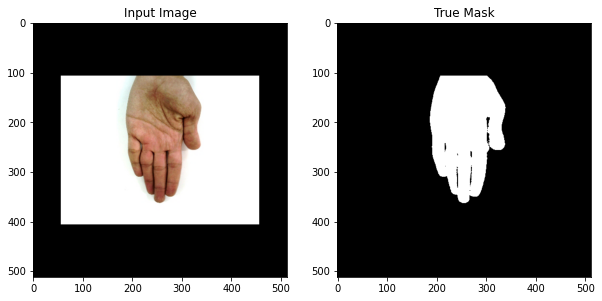

In [ ]:
x,y = next(train_generator)
print(x.shape, y.shape)
display([x[0], y[0][...,0]])

## Compile


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.backend import clear_session

# Free up RAM in case the model definition cells were run multiple times
clear_session()
#input_shape = (None,None) + (1,) # downscaled_img_size

# create the network and compile it with its optimizer
if model_name == 'UNet':
    model = UNet( input_size = input_shape,
                 filters=num_filters, dropout_value=dropout_value,
                 spatial_dropout=spatial_dropout, average_pooling=average_pooling,
                 activation=activation, pixel_shuffle = pixel_shuffle,
                 data_augmentation = extra_tf_data_augmentation,
                 )
elif model_name == 'ResUNet':
    model = ResUNet( input_size = input_shape,
                    filters=num_filters,
                    batchnorm=False, spatial_dropout=spatial_dropout,
                    average_pooling=average_pooling,
                    activation=activation, separable=False,
                    dropout_value=dropout_value, num_classes = out_channels,
                    pixel_shuffle = pixel_shuffle,
                    data_augmentation = extra_tf_data_augmentation,)

if optimizer_name == 'SGD':
    optim =  tf.keras.optimizers.SGD(
            lr=lr, momentum=0.99, decay=0.0, nesterov=False)
elif optimizer_name == 'Adam':
    optim = tf.keras.optimizers.Adam( learning_rate=lr )
elif optimizer_name == 'rmsprop':
    optim = tf.keras.optimizers.RMSprop( learning_rate=lr )
model.summary()

if loss_acronym == 'bce':
    loss_funct = 'binary_crossentropy'
elif loss_acronym == 'bce_dice':
    loss_funct = bce_dice_loss

eval_metric = jaccard_index

# compile the model with the specific optimizer, loss function and metric
model.compile(optimizer=optim, loss=loss_funct, metrics=eval_metric)#, loss_weights = {"img": alpha, "mask": beta})

# callback for early stop
earlystopper = EarlyStopping(patience=patience, verbose=1, restore_best_weights=True)

if schedule == 'oneCycle':
    # callback for one-cycle schedule
    steps = np.ceil(train_data_size / batch_size_value) * numEpochs
    #steps = np.ceil(len(X_train) / batch_size_value) * numEpochs
    lr_schedule = OneCycleScheduler(lr, steps)
elif schedule == 'reduce':
    # callback to reduce the learning rate in the plateau
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=patience, min_lr=(lr/10))
else:
    lr_schedule = None

callbacks = [earlystopper] if lr_schedule is None else [earlystopper, lr_schedule]

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 random_flip (RandomFlip)       (None, None, None,   0           ['input_1[0][0]']                
                                3)                                                                
                                                                                                  
 conv2d_1 (Conv2D)              (None, None, None,   896         ['random_flip[4][0]']            
                                32)                                                           

### show model architecture
Have a quick look at the resulting model architecture:

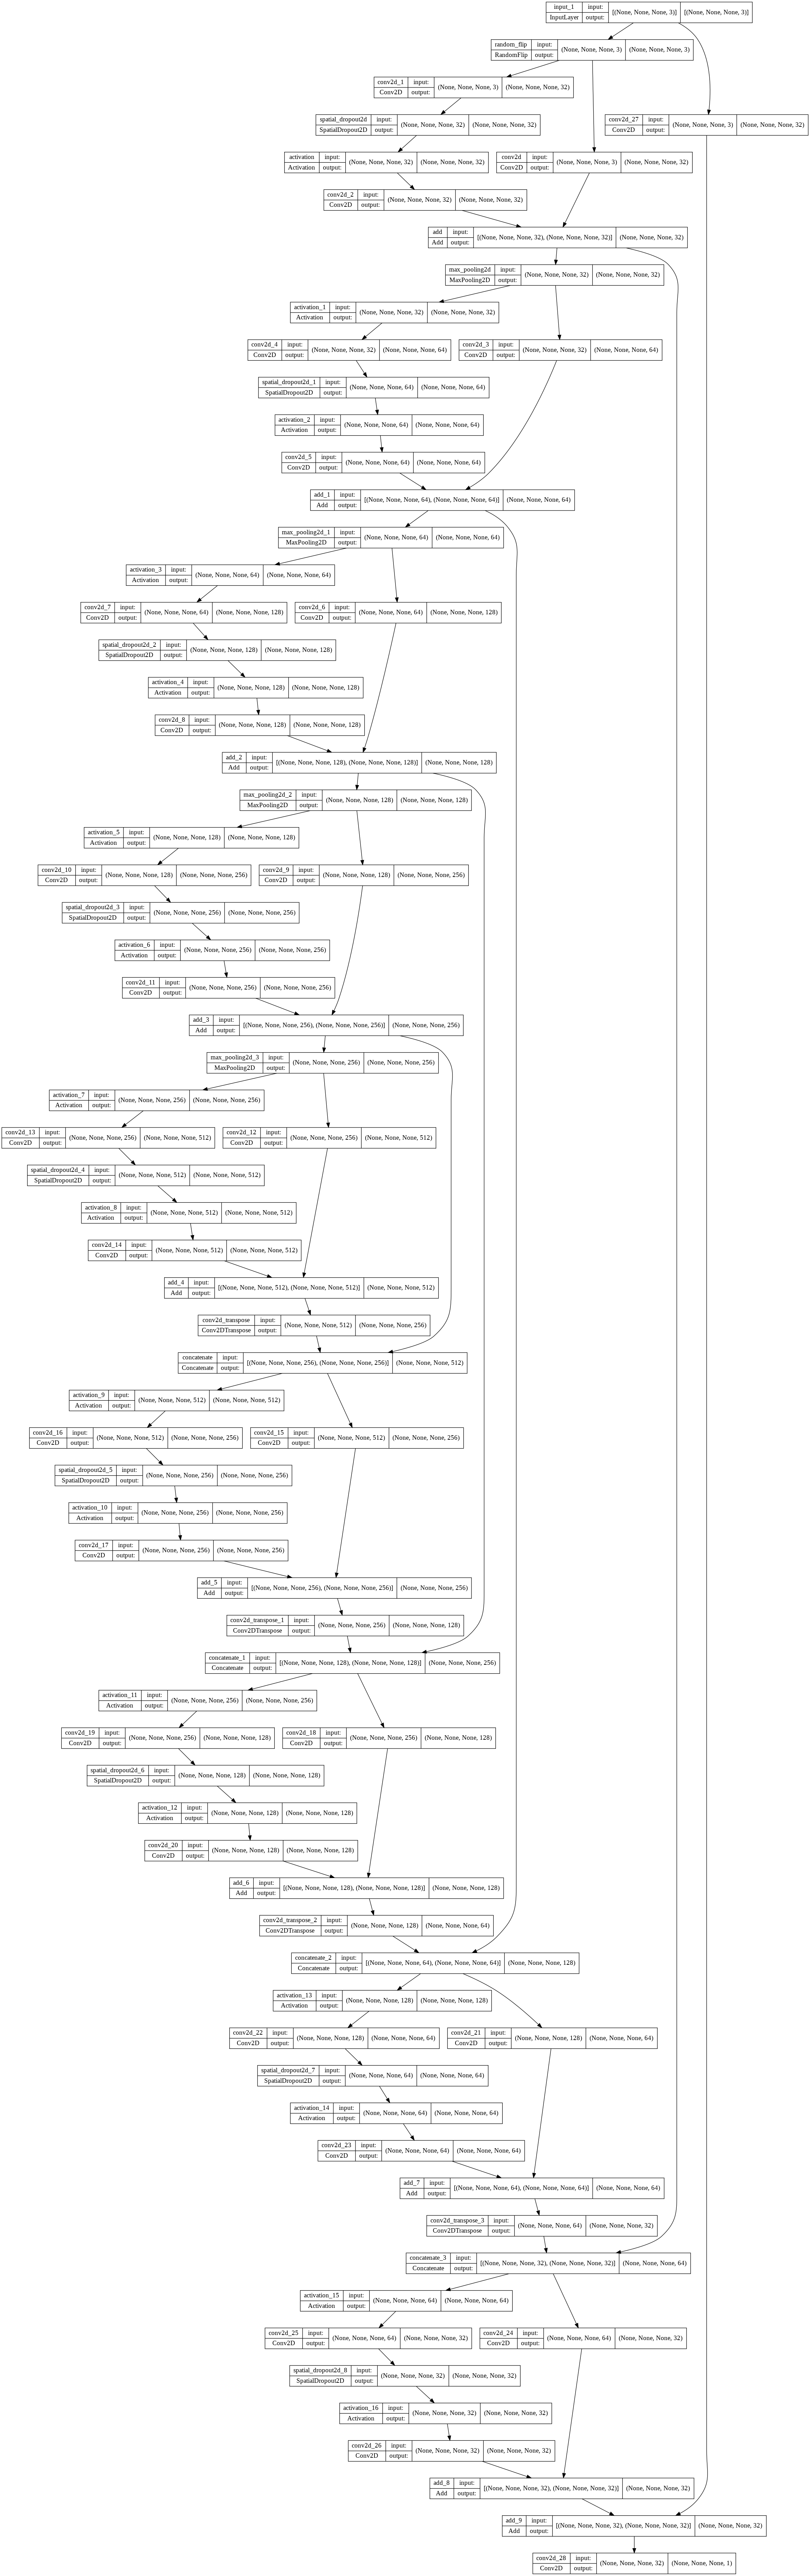

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

### Load saved model

In [ ]:
if use_saved_model:
    # Restore the weights
    model.load_weights(model_path)

    # compile the model with the specific optimizer, loss function and metric
    model.compile(optimizer=optim, loss=loss_funct, metrics=eval_metric)
    print("Weights loaded, and compiled")


## Train model

In [ ]:
history = model.fit(train_generator, validation_data=val_generator,
                    validation_steps=np.ceil(val_data_size/batch_size_value),
                    steps_per_epoch=np.ceil(train_data_size/batch_size_value),
                    epochs=numEpochs, callbacks=callbacks)

Epoch 1/20
 1428/11250 [==>...........................] - ETA: 20:33 - loss: 0.6100 - jaccard_index: 0.1221

### Plot loss - IoU

In [ ]:
metrics = ['loss', 'jaccard_index']
plot_loss_and_metric(metrics, history, figsize=(14,7))

### Save weights

In [ ]:
# Save weights for future reuse
if schedule is None:
    schedule = 'None'
create_dir(out_dir)
out_name = 'weights-{}-bce-nf-{}-bs-{}-{}-{}.h5'.format(
                                            model_name, num_filters,
                                            batch_size_value,
                                            optimizer_name, schedule )
weights_filename = os.path.join(out_dir, out_name)
model.save_weights( weights_filename )
print( 'Saved model as ' + weights_filename )

## Evaluation
\+ display examples

In [ ]:
test_img, test_lbl = get_xy_image_list(test_path)

# Prepare the test data
X_test = [x/255 for x in test_img] # normalize between 0 and 1
X_test = np.asarray(X_test, dtype=np.float32) # add extra dimension
Y_test = [x[:,:,:1]/255 for x in test_lbl] # normalize between 0 and 1, and get single channel
Y_test = np.asarray(Y_test, dtype=np.float32) # add extra dimension

# Now, we calculate the final test metrics
preds_test = model.predict(X_test, batch_size=batch_size_value) # predict per patch

iou = []
for i in range(0, len(preds_test)):
    iou.append( jaccard_index(Y_test[i], preds_test[i] >= 0.5 ))
mean_iou = np.mean(iou)

print("\nTest IoU:", mean_iou)

In [ ]:
#show_predictions_multitask(X_test, Y_test, num=1, var=0)
plt.figure(figsize=(7*4,7))
display([X_test[0], Y_test[0,:,:,0], preds_test[0,:,:,0]>=.5, preds_test[0,:,:,0]], custom_size = True)
plt.figure(figsize=(7*4,7))
display([X_test[-1], Y_test[-1,:,:,0], preds_test[-1,:,:,0]>=.5, preds_test[-1,:,:,0]], custom_size = True)